In [11]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import pickle 
import time
import random #remember to do this in class
from sklearn import datasets
import matplotlib.pyplot as plt
from preprocess import preprocessing as pre
import epl.src.computeResults as compResults
from numpy.matlib import repmat
#import epl.src.multi_pattern_learning.epl_multi_pattern_learning 
#from epl.src.multi_pattern_learning.epl_multi_pattern_learning import EPLMultiPatternLearning

from sklearn.decomposition import PCA


ModuleNotFoundError: No module named 'epl'

LOAD AND GENERATE DATA


In [3]:
# load the digits dataset which consists of 8X8 images of digits
digits = datasets.load_digits()
images = digits.images
targets = digits.target
# create a map of {digt->list of images of the digits}
image_dict = {n : [] for n in range(10)}
for t, img in zip(targets, images):
    image_dict[t].append(img)

In [4]:

numPatterns = 6
#randomly choose 6 digits
digits = np.array([0, 2, 4, 5, 7, 9], ndmin = 2)


In [5]:
#CAN STAY IN CODE

#define utility functions
#create the training dataset by choosing the appropriate images of the digts to be learned
def get_training_data(digits, fourX=True, idx=0):
    train_data = []
    for digit in digits:
        training_image = image_dict[digit][idx]
        print(training_image)
        training_image = np.ndarray.astype(training_image, int)
        if fourX: training_image = (training_image//4)*4
        training_image = np.ndarray.flatten(training_image).tolist()
        print(training_image)
        train_data.append(training_image)
    return train_data

In [6]:
# generate the training data
digitss = [0, 2, 4, 5, 7, 9]
train_data = np.array(get_training_data(digits=digitss))

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[0, 0, 4, 12, 8, 0, 0, 0, 0, 0, 12, 12, 8, 12, 4, 0, 0, 0, 12, 0, 0, 8, 8, 0, 0, 4, 12, 0, 0, 8, 8, 0, 0, 4, 8, 0, 0, 8, 8, 0, 0, 4, 8, 0, 0, 12, 4, 0, 0, 0, 12, 4, 8, 12, 0, 0, 0, 0, 4, 12, 8, 0, 0, 0]
[[ 0.  0.  0.  4. 15. 12.  0.  0.]
 [ 0.  0.  3. 16. 15. 14.  0.  0.]
 [ 0.  0.  8. 13.  8. 16.  0.  0.]
 [ 0.  0.  1.  6. 15. 11.  0.  0.]
 [ 0.  1.  8. 13. 15.  1.  0.  0.]
 [ 0.  9. 16. 16.  5.  0.  0.  0.]
 [ 0.  3. 13. 16. 16. 11.  5.  0.]
 [ 0.  0.  0.  3. 11. 16.  9.  0.]]
[0, 0, 0, 4, 12, 12, 0, 0, 0, 0, 0, 16, 12, 12, 0, 0, 0, 0, 8, 12, 8, 16, 0, 0, 0, 0, 0, 4, 12, 8, 0, 0, 0, 0, 8, 12, 12, 0, 0, 0, 0, 8, 16, 16, 4, 0, 0, 0, 0, 0, 12, 16, 16, 8, 4, 0, 0, 0, 0, 0, 8, 16, 8, 0]
[[ 0.  0.  0.  1. 11.  0. 

In [7]:
def generateTestingData(trainingData, occlusionPercent, numTestSamples,
                        sensorDynamicRange=16):  #15 to 16
    """ generate synthetic testing data for EPL network"""
    data = trainingData
    p = occlusionPercent
    n = numTestSamples
    occludedData = []
    nsensors = len(data[0])

    for i in range(0, len(data)):
        ndim = len(data[i])  # dimension of data
        for j in range(0, n):
            occludedData.append([])
            affected_ids = random.sample(range(ndim), int(p * ndim))
            for k in range(0, ndim):
                if k in affected_ids:
                    occludedData[i * n + j].append(
                        random.randint(0, sensorDynamicRange))
                else:
                    occludedData[i * n + j].append(data[i][k])
    return occludedData
numTestSamples = 5
occlusionPercent = 0.2 # randomly perturb only 20% of the image pixels
test_data = np.array(generateTestingData(trainingData=train_data,
                                occlusionPercent=occlusionPercent,
                                numTestSamples=numTestSamples))

# plot train_data and test_data

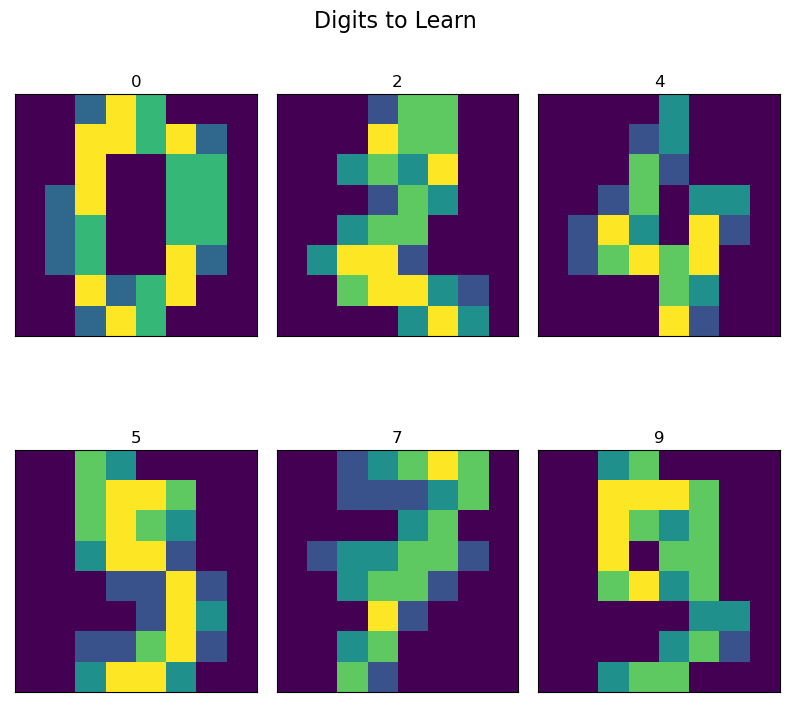

In [8]:
# Train Data
pre.plot_images(digitss, train_data, title="Digits to Learn")

In [9]:
"""
Test Data:

can have 10 rows instead of 2 to show all of test_data
"""
test_digits = repmat(digitss, numTestSamples,1).T.reshape((1,-1))
test_digitss = repmat(digits, numTestSamples,1).T.flatten()
pre.plot_images(test_digitss, test_data, title="10 by 3 Noisy samples of the learned digits",nrows=10, ncols=3)
#pre.plot_images(digits, test_data, title="2 by 3 Noisy samples of the learned digits",nrows=2, ncols=3)

NameError: name 'repmat' is not defined

# scaling and defining trainingOdors and testOdors

In [10]:
scale = 15.0
# use preprocessing function
# scaling is fine

train_data -= train_data.min()
train_data = train_data*(scale/train_data.max())
trainingOdors = train_data.astype(np.int64)

test_data -= test_data.min()
test_data = test_data* scale/test_data.max()
testOdors = test_data.astype(np.int64)

## training and testing

In [ ]:
from lib import epl
nGamma = 5
nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
nGammaPerOdor = 5
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1,nGammaPerOdor = 10); #nGammaPerOdor_training = 10 define early in code
    # changed nGammaPerOdor from 5 to 10
    epl.GClayer.invokeNeurogenesis();
#added this for loop to change structure of epl.gammaCode
for i in range(0, len(trainingOdors)):
    sniff(trainingOdors[i], learn_flag=0, nGammaPerOdor = nGammaPerOdor);
    
#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0, nGammaPerOdor = nGammaPerOdor); 
    if((i+1)%10==0 and (i+1)!=0):
        print(str(i+1) + " odors tested"); 
t2 = time.time(); 
sim_time = t2-t1
print("Simulation Duration = " + str(sim_time) + "s")


## epl gammaCode parsing


In [ ]:
nGammaPerOdor_training = 10
#Remember the first training loop uses nGammaPerOdor = 10
#The added 5 refers to the second loop of training which uses the default variable in sniff for nGammaPerOdor
#The added len(testOdors) * 5 refers to the third testing loop which uses the dafault variable in sniff for nGammaPerOdor
# len(testOdors) = len(digits) * numTestSamples because generateTestOdors generates 5 noisy versions of each test digit
# this is in order of loops
gammaCode_size = len(trainingOdors)*(nGammaPerOdor_training + nGammaPerOdor) + digits.size* numTestSamples * nGammaPerOdor
#digits.size=len(trainingOdors) should have numTrainingSamples
#rename numTestSamples to numPerturbedSamples
(gammaCode_size,len(epl.gammaCode))

In [ ]:
numTestSamples

In [ ]:
len(epl.gammaCode[0])

In [ ]:
len(epl.gammaCode)

In [ ]:
testOdors.shape

In [ ]:
trainingOdors.shape

In [ ]:

trained = np.array(epl.gammaCode[len(trainingOdors)*10:len(trainingOdors)*15]).reshape(nGammaPerOdor, 6, -1)
tested = np.array(epl.gammaCode[len(trainingOdors)*15:]).reshape(nGammaPerOdor, 30, -1)

In [ ]:
trained[0][0]==trained[0][5]

In [ ]:
len(testOdors)/nGammaPerOdor

In [ ]:
trained.shape

In [ ]:
tested.shape #tested[-1]

In [ ]:
# jaccardSimilarity(trained[-1,i], tested[-1,j])
# i is the consecutive original digit. j is the consecutive test digit
# make an array from nested loop
def jaccardSimilarity(l1=[], l2=[]):
    """ computes Jaccard similarity"""
    list1 = []
    list2 = []
    for i in range(0, len(l1)):
        list1.append((i, l1[i]))
        list2.append((i, l2[i]))
    set1 = set(list1)
    set2 = set(list2)
    intersectionSize = len(set.intersection(set1, set2))
    unionSize = len(set.union(set1, set2))
    # print intersectionSize, unionSize;
    return round(intersectionSize/float(unionSize), 4)
def computeSimilarity(l1, l2):
    """ computes similarity index """
    return jaccardSimilarity(l1, l2)

In [ ]:

true_negative = 0
false_positive = 0


SImatrix = np.zeros((len(digits[0]), len(test_digits[0])), dtype =float)  
for i in range(0, len(trained[-1])):
    for j in range(0, len(tested[-1])):
        SImatrix[i][j] = (computeSimilarity(trained[-1][i], tested[-1][j]))
        
        """
        if SImatrix[i][j]> 0.75: #and test_digits[sim_index] == test_digits[i*5]: 
            true_positive+=1
        elif SImatrix[i][j]< 0.75: #and test_digits[sim_index] == test_digits[i*5]:
            false_negative+=1
        elif SImatrix[i][j] < 0.75: #and test_digits[sim_index] != test_digits[i*5]:
            true_negative+=1
        elif SImatrix[i][j] > 0.75: #and test_digits[sim_index] != test_digits[i*5]:
            false_positive+=1
        else:
            print("error")
#target recognition matrix to find what is above and below .75 
true_positive, true_negative, false_positive, false_negative
"""
decisionMatrix = (SImatrix> 0.75)

In [ ]:
SImatrix

In [ ]:
decisionMatrix 

In [ ]:
truthMatrix = np.equal(digits.T, test_digits)
truthMatrix.shape
#digits which is a 2d array, use reshape to 
#operations broadcasting when comparing two arrays of different dimensions

In [ ]:
#this is not decisionMatrix xor truthMatrix
#returns all the places where the decision is correct (trues are trues and falses re false)
#take a look at this logic
# Try this alternative expression: correct = not (decisionMatrix xor truthMatrix)
correct = ~(decisionMatrix ^ truthMatrix)

In [ ]:
correctID = np.count_nonzero(correct)
per_correct = float(correctID)/SImatrix.size

In [ ]:
(per_correct, sim_time)

In [ ]:
#repmat(digits, len(test_digits)-1)

In [ ]:
SImatrix.size

In [ ]:
pre.plotFigure3b(SImatrix, epl.nMCs, nGamma=5,figsize = (3,12))